# Trees

In this notebook we compare tree-based models against the strongest models and baselines from `04-new-models.ipynb`. We use the same v2 structural feature set from `data/processed/structural-v1.csv` and the same `log1_price` target, so the final test metrics are directly comparable to the MLP v2 and its baselines.

For the tree models we first created multiple configs under `configs/multiple/`. These configs define search spaces for random forests and boosted trees. The pipeline `cross-val-tree-multiple.py` wraps preprocessing and the model in a scikit-learn pipeline, runs `RandomizedSearchCV`, and stores the actually selected parameters as artifacts. After that search, we copied the best parameters into the single configs and ran `full-train-test-tree.py` once per model on the full training split. The final comparison below uses those full single-run artifacts.


In [1]:
import json
from team_project.data.loading import (
    load_cross_validation_linear_baseline,
    load_cross_validation_mean_baseline,
    load_data_multi_run_cross_validation,
    load_final_linear_baseline,
    load_final_mean_baseline,
    load_final_metrics,
    load_tree_best_params,
    load_tree_search_metadata,
)
from team_project.data.summaries import summarize_cross_validation_runs

import pandas as pd
from team_project.visualization.plotting import (
    configure_notebook_style,
    plot_cv_rmse_comparison,
    plot_test_error_comparison,
    plot_test_r2_comparison,
)


In [2]:
configure_notebook_style()


# Search Results

In [3]:
TREE_EXPERIMENTS = {
    "Random forest": "random-forest-v1",
    "Boosted tree": "boosted-tree-v1",
}
optimal_parameters = pd.DataFrame([
    {
        "model": model_name,
        "experiment": experiment_name,
        "best_params": json.dumps(
            load_tree_best_params(experiment_name),
            sort_keys=True,
        ),
    }
    for model_name, experiment_name in TREE_EXPERIMENTS.items()
])

optimal_parameters


,model,experiment,best_params
0,Random forest,random-forest-v1,"{""bootstrap"": true, ""max_depth"": 20, ""max_feat..."
1,Boosted tree,boosted-tree-v1,"{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_..."


The table lists the parameters selected by the randomized searches. We then used these values in the single tree configs and trained one final model per tree family on the full training split before evaluating on the held-out test set.


# Cross Validation



In [4]:
mlp_lr_runs = load_data_multi_run_cross_validation("mlp-v2-learning-rates")
mlp_lr_summary = summarize_cross_validation_runs(
    mlp_lr_runs, "lr", "learning_rate"
)
best_mlp_lr_run = mlp_lr_summary.iloc[0]

cv_mean_baseline_metrics = load_cross_validation_mean_baseline("mlp-v2-learning-rates")
cv_linear_baseline_metrics = load_cross_validation_linear_baseline("mlp-v2-learning-rates")

tree_cv_rows = []
for model_name, experiment_name in TREE_EXPERIMENTS.items():
    metadata = load_tree_search_metadata(experiment_name)
    tree_cv_rows.append({
        "model": model_name,
        "cv_rmse": -metadata["search"]["best_score"],
        "n_iter": metadata["search"]["n_iter"],
        "k": metadata["data_split"]["k"],
    })

cv_summary = pd.DataFrame([
    *tree_cv_rows,
    {
        "model": f"MLP v2, lr={best_mlp_lr_run['learning_rate']}",
        "cv_rmse": best_mlp_lr_run["final_val_mse"] ** 0.5,
        "n_iter": None,
        "k": None,
    },
    {
        "model": "Mean baseline",
        "cv_rmse": cv_mean_baseline_metrics["mse"] ** 0.5,
        "n_iter": None,
        "k": None,
    },
    {
        "model": "Linear baseline",
        "cv_rmse": cv_linear_baseline_metrics["mse"] ** 0.5,
        "n_iter": None,
        "k": None,
    },
])

cv_summary.sort_values("cv_rmse").round({"cv_rmse": 4})


,model,cv_rmse,n_iter,k
0,Random forest,0.5169,30.0,5.0
1,Boosted tree,0.5190,30.0,5.0
4,Linear baseline,0.5448,NaN,NaN
2,"MLP v2, lr=0.001",0.5499,NaN,NaN
3,Mean baseline,0.7488,NaN,NaN


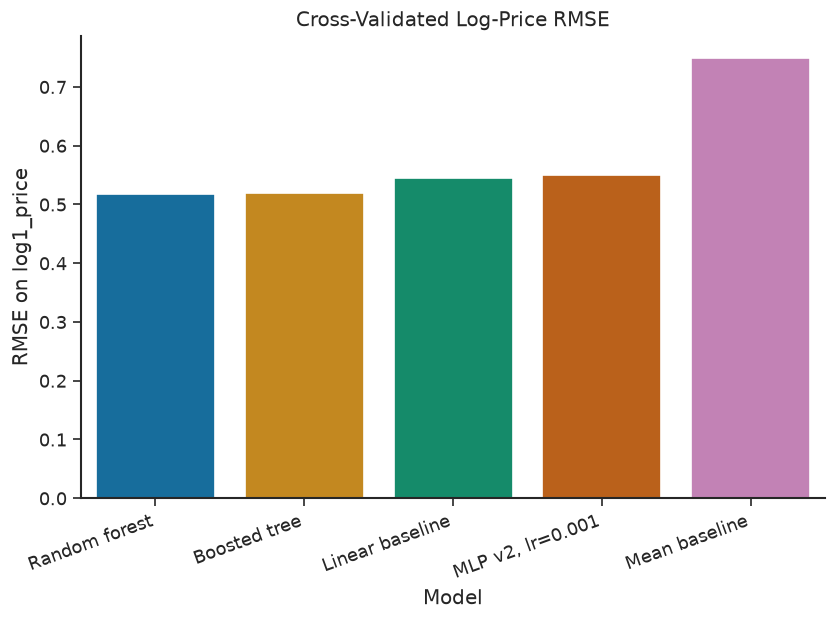

In [5]:
plot_cv_rmse_comparison(cv_summary)


The cross-validation results suggest that both tree families improve over the MLP v2 and the simple baselines on the v2 feature set. The random forest and boosted tree are close to each other, which is a good sign that the result is not just one model family behaving unusually.


# Test Performance

After selecting the tree hyperparameters from cross-validation, we trained each tree model once on the full training split and evaluated on the held-out test set. We compare those final tree artifacts with the MLP v2, the mean baseline, and the linear baseline from notebook 04.


In [6]:
test_performance = pd.DataFrame([
    {"model": "Random forest", **load_final_metrics("random-forest-v1")},
    {"model": "Boosted tree", **load_final_metrics("boosted-tree-v1")},
    {"model": "MLP v2", **load_final_metrics("mlp-v2")},
    {"model": "Mean baseline", **load_final_mean_baseline("mlp-v2")},
    {"model": "Linear baseline", **load_final_linear_baseline("mlp-v2")},
])

test_performance = test_performance[["model", "mse", "rmse", "mae", "r2"]]
test_performance.sort_values("rmse").round({
    "mse": 4,
    "rmse": 4,
    "mae": 4,
    "r2": 4,
})


,model,mse,rmse,mae,r2
1,Boosted tree,0.2201,0.4692,0.3601,0.5731
0,Random forest,0.2211,0.4703,0.3571,0.5711
4,Linear baseline,0.2707,0.5203,0.3838,0.4750
2,MLP v2,0.2709,0.5205,0.3864,0.4747
3,Mean baseline,0.5163,0.7185,0.5719,-0.0012


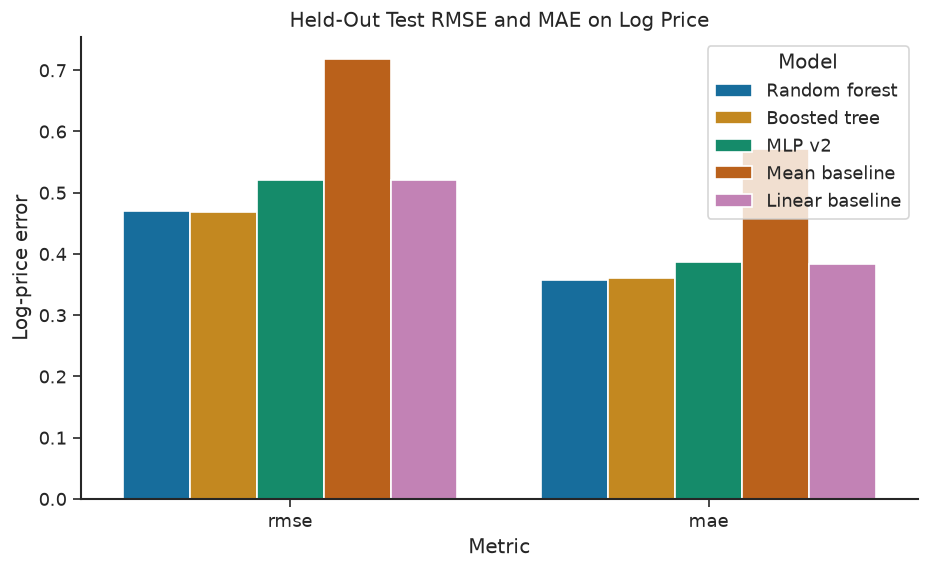

In [7]:
plot_test_error_comparison(test_performance)


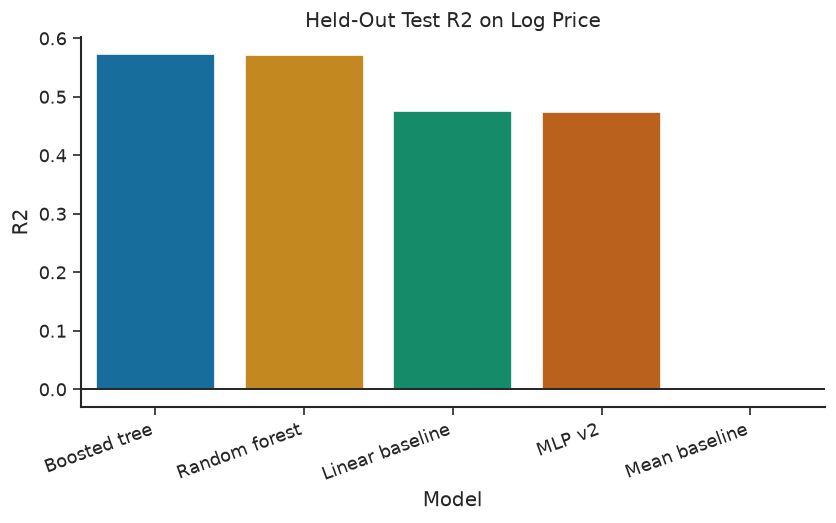

In [8]:
plot_test_r2_comparison(test_performance)


The held-out test set supports the cross-validation result. The tuned random forest and boosted tree both improve over the MLP v2 and over the linear baseline on RMSE, MAE, and R2. The two tree models are very close, with the boosted tree slightly ahead on RMSE and R2 in this run. Overall, we see that the v2 structural features are useful for linear and neural models, but the tree models extract more nonlinear signal from the same tabular data.
